In [ ]:
# Uploading the dataset
from google.colab import files
uploaded_dataset = list(files.upload())[0]

Saving cleaned_real_estate.csv to cleaned_real_estate.csv


In [2]:
# import required libraries
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

In [ ]:
# Required to dump the model
import joblib

In [3]:
# Loading the preprocessed data
data = pd.read_csv(uploaded_dataset)

In [4]:
data.head()

,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt
0,0.117684,0.227638,0.333333,0.003587,0.333333,0.0,0.256978
1,0.089664,0.401663,0.666667,0.003587,0.333333,0.0,0.117963
2,0.075094,0.178326,0.000000,0.436827,0.000000,0.0,0.201682
3,0.162516,0.479931,0.666667,0.712919,0.333333,0.0,0.181380
4,0.200624,0.686353,0.666667,0.790241,0.666667,0.0,0.159936


In [ ]:
# Separating dependent and independent variables
X = data.drop(columns=['Price']) # independent variables
y = data['Price'] # target variable

In [6]:
# Splitting data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Get importance
importance = model.feature_importances_

# Convert to DataFrame
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance)

          feature    importance
5  Price_Per_SqFt  6.008980e-01
0       Area_SqFt  3.990982e-01
2        Location  2.572377e-06
1        Bedrooms  6.500915e-07
3       Bathrooms  5.513387e-07
4          Source  0.000000e+00


In [8]:
# Calculating permutaion_importance
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)

importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

print(importance)

          feature    importance
5  Price_Per_SqFt  1.410512e+00
0       Area_SqFt  9.340069e-01
1        Bedrooms  6.574020e-08
3       Bathrooms  5.272391e-08
2        Location  2.234250e-08
4          Source  0.000000e+00


In [15]:
# Price_Per_SqFt, Area_SqFt, Bedrooms Bathrooms are important features.
# The importance of location changed abruptly in permutation importance, hence location is least important
# also the source is least important feature

# we can remove location and source variable during MODEL ENSEMBLING

In [ ]:
# Saving the Model
joblib.dump(model, "random_forest_regressor.pkl")

['random_forest_regressor.pkl']

In [ ]:
# Downloading the model
files.download("random_forest_regressor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Getting test results
y_predicted = model.predict(X_test)

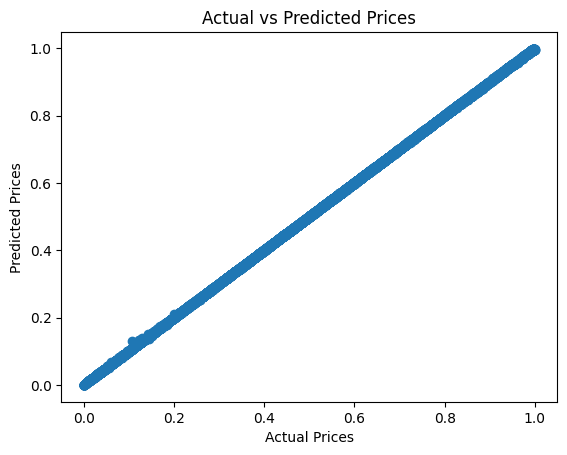

In [ ]:
# Plotting the Test Results and Expected Values
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_predicted)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

In [ ]:
# Calculating Model Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predicted)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.00015865469322161953
RMSE: 0.0003049208998846036
R² Score: 0.9999977364975599


# Model Evaluation Metrics :

  ### Mean Absolute Error
    MAE : ~ 0.00016  
  ### Root Mean Square Error :    
    RMSE : ~ 0.000305  
  ### R-squared Score :     
    R2 = ~0.9999977

> The `r2` Value can be used as the metric for accuracy : 

- `r2` == `1` -- **Perfect model**

- `r2` == `0` -- **Poor model** 